### Analyses

This notebook is for analysing data. Key findings:  
 
1.RMS shows clear spikes in the raw data;  
2.Spectrums given by STFT are interesting. Some spectrums have multiple "light columns", some are only strong at low frequencies and weak at high frequencies. There are still some spectrums where the patterns of each frequency band are the same.

### Initialize

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
from scipy.signal import stft
from scipy.signal import butter, filtfilt, welch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [46]:
feature_dim = (0, None)    # (0, None) to use all features
sample_idx = 6200          # 8027 samples to choose

In [47]:
LOGIT_TO_PHONEME = [
    'BLANK',
    'AA', 'AE', 'AH', 'AO', 'AW',
    'AY', 'B',  'CH', 'D', 'DH',
    'EH', 'ER', 'EY', 'F', 'G',
    'HH', 'IH', 'IY', 'JH', 'K',
    'L', 'M', 'N', 'NG', 'OW',
    'OY', 'P', 'R', 'S', 'SH',
    'T', 'TH', 'UH', 'UW', 'V',
    'W', 'Y', 'Z', 'ZH',
    ' | ',
]

### Load Data

In [48]:
# load all training files
data_dir = "../../data/hdf5_data_final"     # modify as needed
folders = [os.path.join(data_dir, folder) for folder in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, folder))]

files = []
for folder in folders:
    files.extend([os.path.join(folder, file) for file in os.listdir(folder) if file == "data_train.hdf5"])
len(files)

45

In [49]:
class MultiFileDataset(Dataset):
    def __init__(self, file_paths, feature_dim):
        """
        Args:
            file_paths (list): List of HDF5 file paths
            feature_dim (tuple): Tuple indicating the feature dimension range to select
        """
        self.file_paths = file_paths
        self.index_map = []  # a map from global index to (file_idx, sample_idx)
        self.feature_dim = feature_dim

        # construct the index map
        for file_idx, file_path in enumerate(file_paths):  # iterate over each file
            with h5py.File(file_path, 'r') as f:
                num_samples = len(f.keys())                # each key is a sample
                self.index_map.extend([(file_idx, i) for i in range(num_samples)])

        self.data = {}

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        """
        Args:
            idx (int): Global index of the sample
        """
        file_idx, sample_idx = self.index_map[idx]   # get file and sample indices
        file_path = self.file_paths[file_idx]

        # load data from the corresponding file
        with h5py.File(file_path, 'r') as f:
            sample_key = list(f.keys())[sample_idx]
            g = f[sample_key]

            self.data['neural_features'] = torch.tensor(g['input_features'][:,self.feature_dim[0]:self.feature_dim[1]])#[feature_dim[0]:feature_dim[1]]
            self.data['n_time_steps'] = torch.tensor(g.attrs['n_time_steps'])
            self.data['seq_class_ids'] = torch.tensor(g['seq_class_ids'][:] if 'seq_class_ids' in g else None)
            self.data['pred_seq'] = [LOGIT_TO_PHONEME[p] for p in self.data['seq_class_ids']]
            self.data['seq_len'] = torch.tensor(g.attrs['seq_len'] if 'seq_len' in g.attrs else None)
            # self.data['transcriptions'] = g['transcription'][:] if 'transcription' in g else None
            # self.data['sentence_label'] = g.attrs['sentence_label'][:] if 'sentence_label' in g.attrs else None
            # self.data['session'] = g.attrs['session']
            # self.data['block_num'] = g.attrs['block_num']
            # self.data['trial_num'] = g.attrs['trial_num']

        return self.data['neural_features'], self.data['n_time_steps'], self.data['seq_class_ids'][:self.data['seq_len']], self.data['seq_len'], self.data['pred_seq']

In [50]:
dataset = MultiFileDataset(files, feature_dim)
# print(dataset[sample_idx][4])  # predicted phoneme sequence

### RMS

/tmp/ipykernel_923/2995584282.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  eeg = np.array(X)


EEG shape: (576, 512)


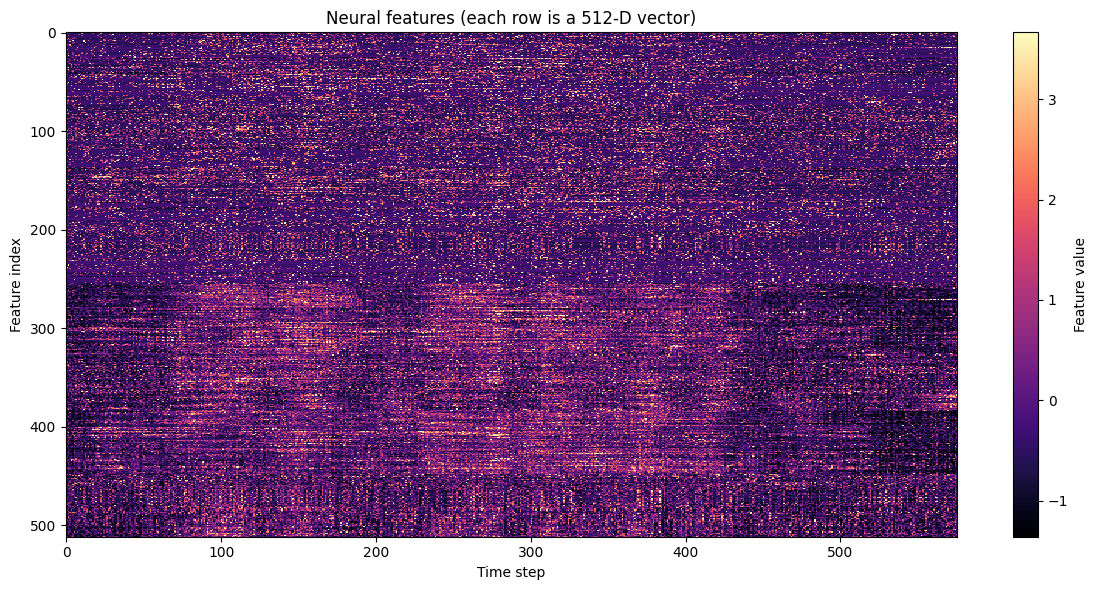

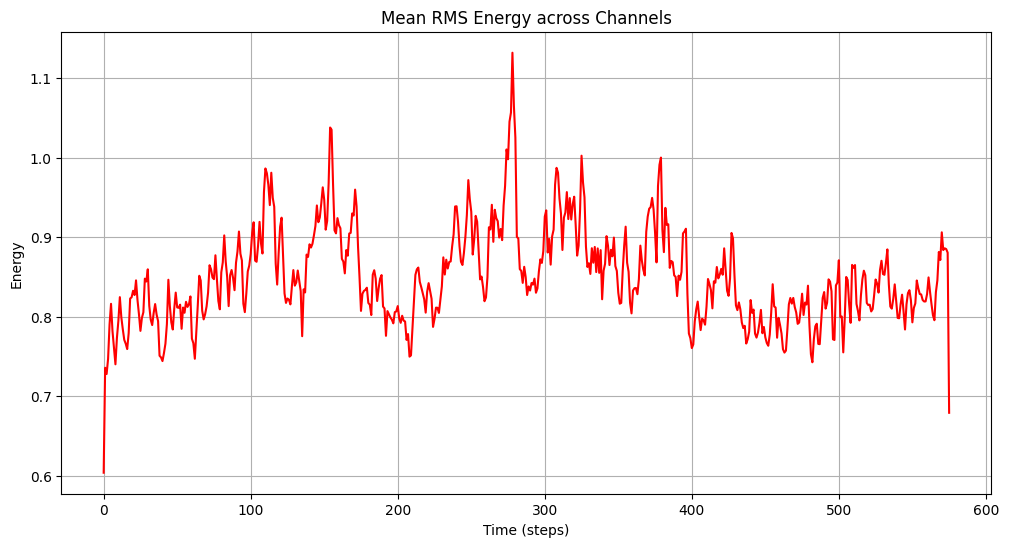

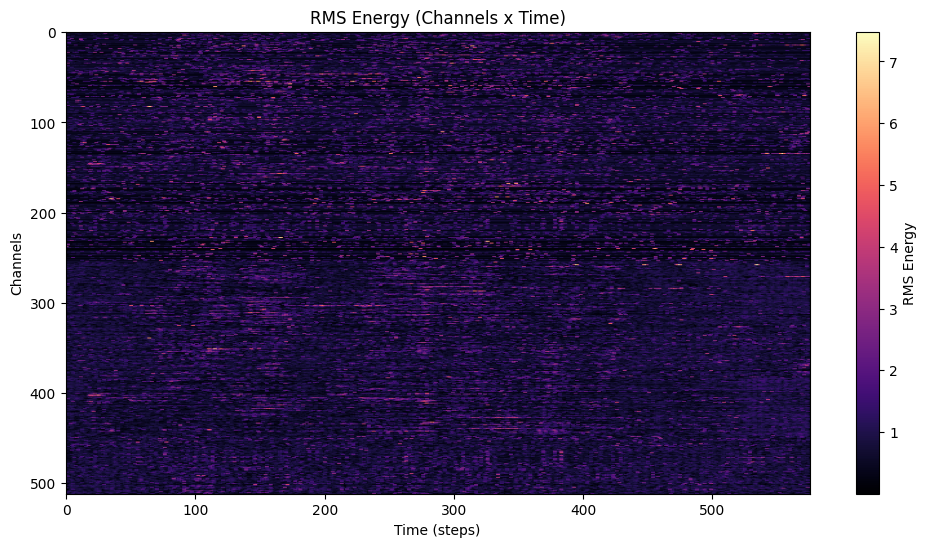

In [ ]:
# rms to check spikes
def sliding_rms(x, win):
    F, T = x.shape  # F feature dimension, T time steps  
    x2 = x**2
    kernel = np.ones(win) / win
    rms = np.sqrt(np.array([np.convolve(x2[ch], kernel, mode="same") for ch in range(F)]))
    return rms


X = dataset[sample_idx][0]  # (T, F)
eeg = np.array(X)    
print("EEG shape:", eeg.shape)

# transport to (F, T)
eeg_T = eeg.T
F, T = eeg_T.shape

rms = sliding_rms(eeg_T, win=3)   # modify window size to show different smoothing effects


# raw data
vmin, vmax = np.percentile(X, [1, 99])
plt.figure(figsize=(12, 6))
im = plt.imshow(
    X.T,                  # (T, F)
    aspect='auto',
    interpolation='nearest',
    cmap='magma',         # could be 'viridis'/'cividis'/'turbo'/'magma'
    vmin=vmin, vmax=vmax
)
plt.colorbar(im, label='Feature value')
plt.ylabel('Feature index')
plt.xlabel('Time step')
plt.title('Neural features (each row is a 512-D vector)')
plt.tight_layout()
plt.show()

# 2) Mean RMS curve (average across all channels)
mean_rms = rms.mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(mean_rms, color="red")
plt.title("Mean RMS Energy across Channels")
plt.xlabel("Time (steps)")
plt.ylabel("Energy")
plt.grid(True)
plt.show()

# 3) RMS of each dimension (window=20 steps ~ 0.4s if fs=50Hz)
plt.figure(figsize=(12, 6))
plt.imshow(rms, aspect="auto", origin="upper", cmap="magma")
plt.colorbar(label="RMS Energy")
plt.title("RMS Energy (Channels x Time)")
plt.xlabel("Time (steps)")
plt.ylabel("Channels")
plt.show()

### STFT

fs, nperseg, noverlap are the parameters for STFT computation. fs is the sampling frequency, nperseg is the length of each segment for STFT, and noverlap is the number of overlapping samples between segments. Increase nperseg for better frequency resolution, and increase noverlap for better time resolution.

STFT output shape: (512, 17, 145)


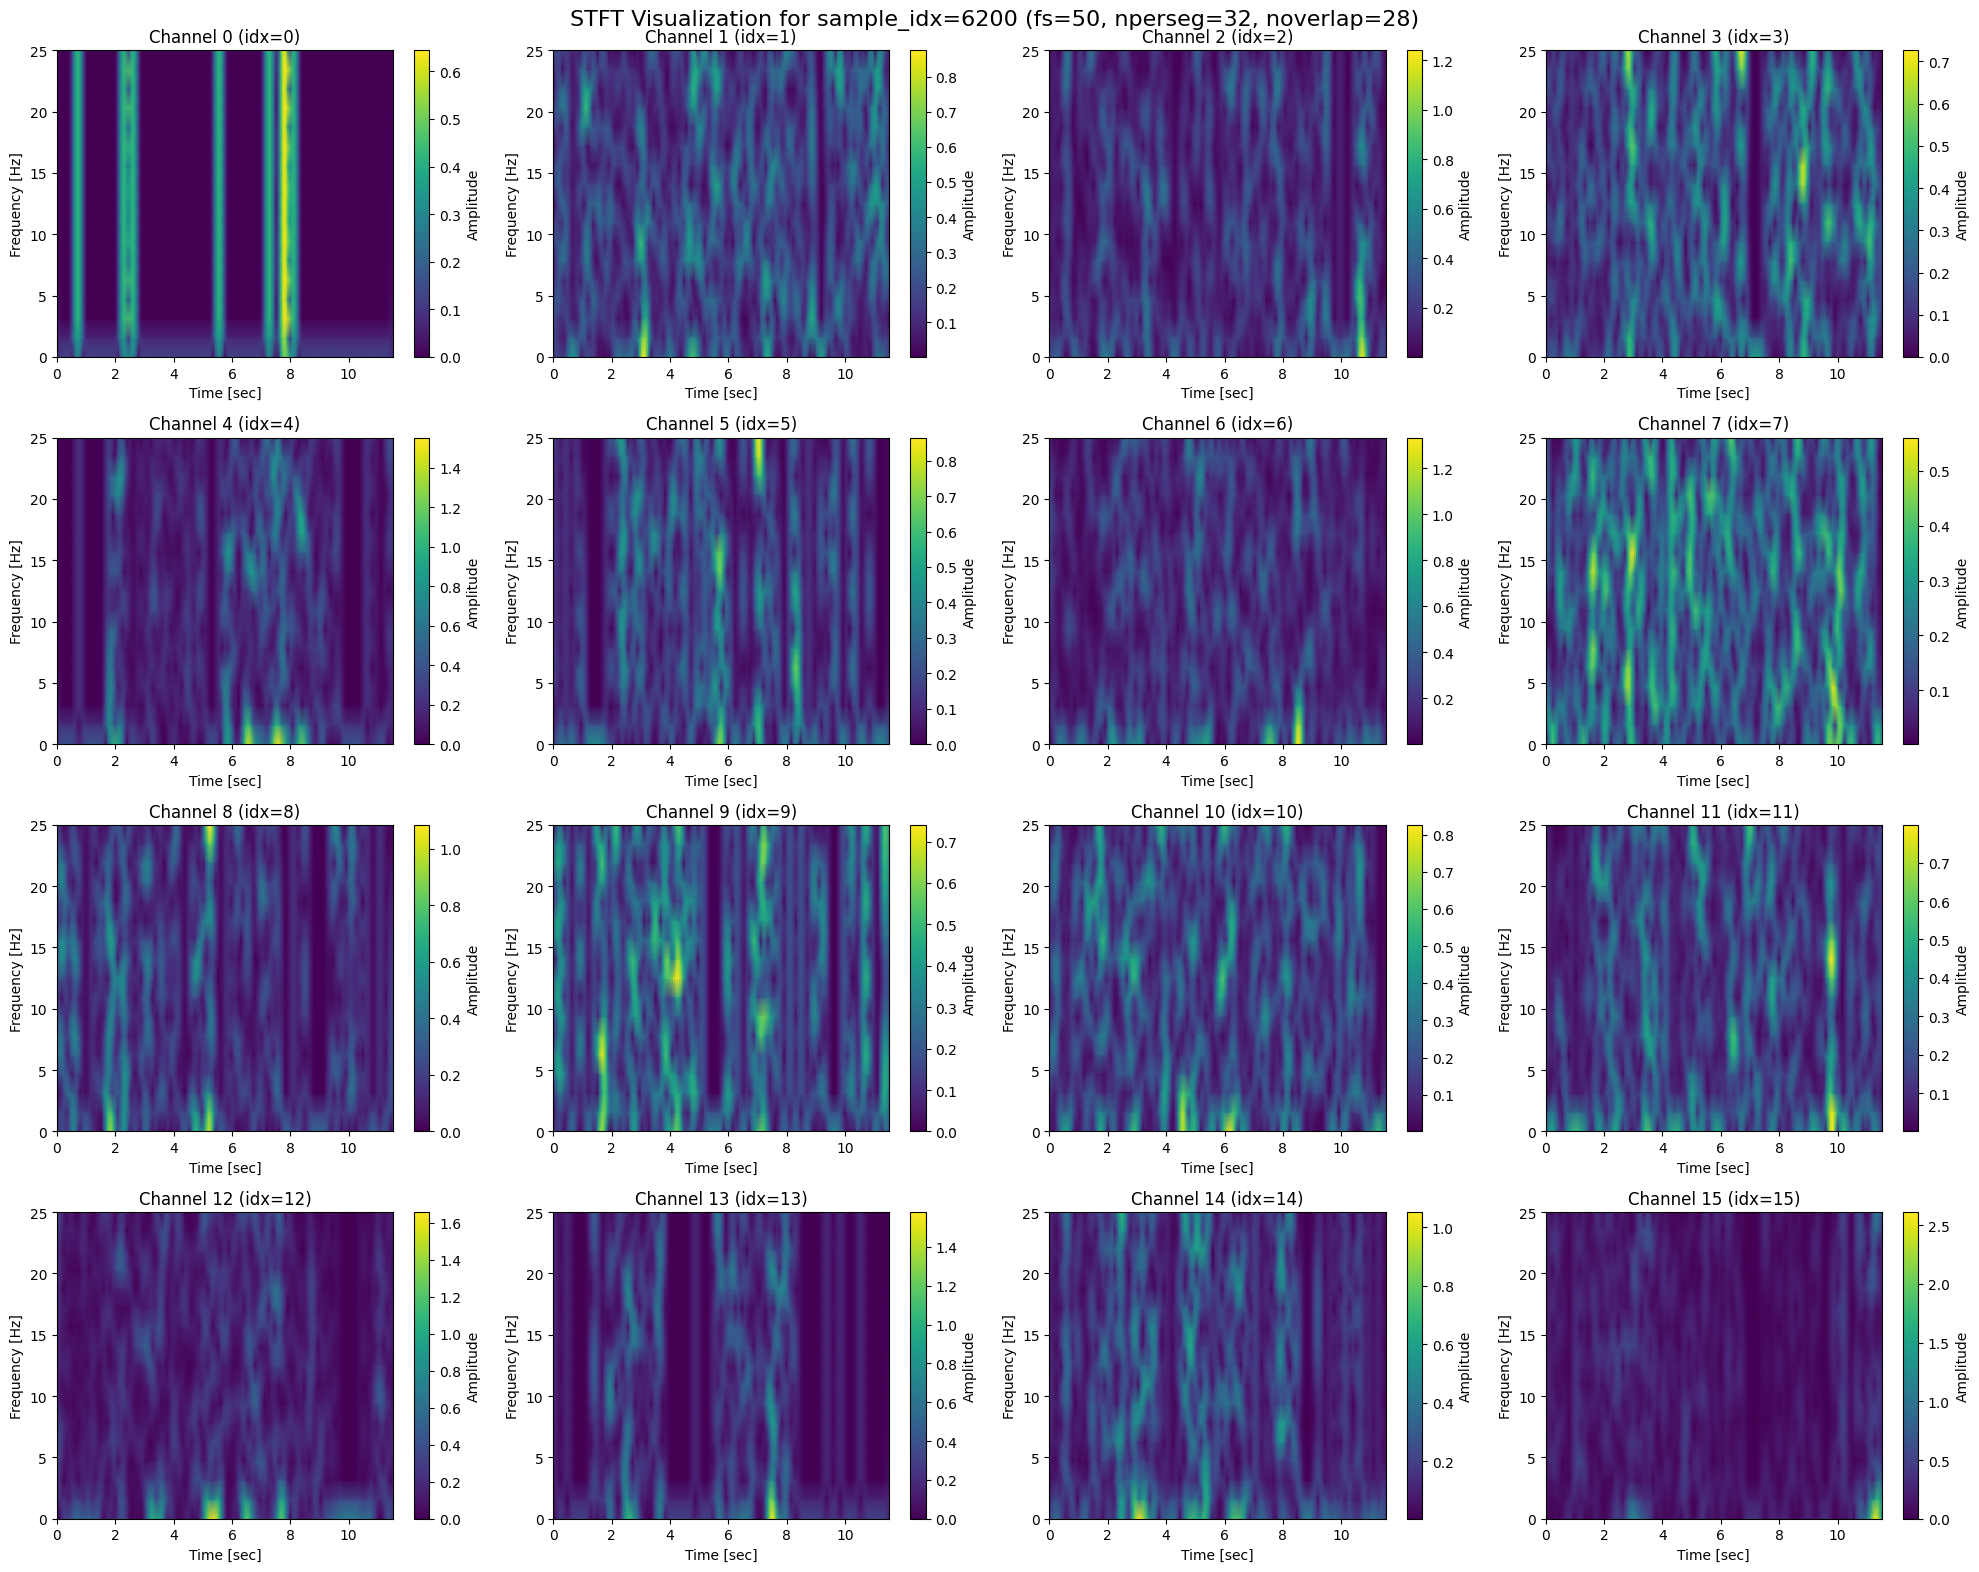

In [ ]:
X = dataset[sample_idx][0]   # (T，F)
X_T = X.T.unsqueeze(0)  # (1, F, T)
eeg = X_T

B, C, T = X_T.shape

# STFT parameters
fs = 50       # 50Hz
nperseg = 32  # nperseg = 32, noverlap = 28 equivalent to performing a 32-28 = 4x downsampling
noverlap = 28 

# STFT for each dimension
stft_list = []
for ch in range(C):
    f, t, Zxx = stft(eeg[0, ch, :], fs=fs, nperseg=nperseg, noverlap=noverlap)
    stft_list.append(np.abs(Zxx))  
stft_array = np.stack(stft_list, axis=0)  # (C, freq_bins, time_bins)，freq_bins is nfft/2+1, nfft default to nperseg

print("STFT output shape:", stft_array.shape)  # (C, F, T_stft)

# visualize the time-frequency plots of the first 16 channels, 4 per row
col = 4
row = 4      # change to 128 for all 512 channels
fig, axes = plt.subplots(row, col, figsize=(20, row * 4))
axes = axes.flatten()

fig.suptitle(f'STFT Visualization for sample_idx={sample_idx} (fs={fs}, nperseg={nperseg}, noverlap={noverlap})', fontsize=16)
for i in range(row * col):
    ax = axes[i]
    im = ax.pcolormesh(t, f, stft_array[i], shading='gouraud')
    ax.set_title(f'Channel {i} (idx={i})')
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [sec]')
    fig.colorbar(im, ax=ax, label='Amplitude')

plt.tight_layout()
plt.show()

In [53]:
stft_array.max(), stft_array.min()

(np.float32(3.3506012), np.float32(4.5742342e-12))

specific_layer shape: (512, 145)


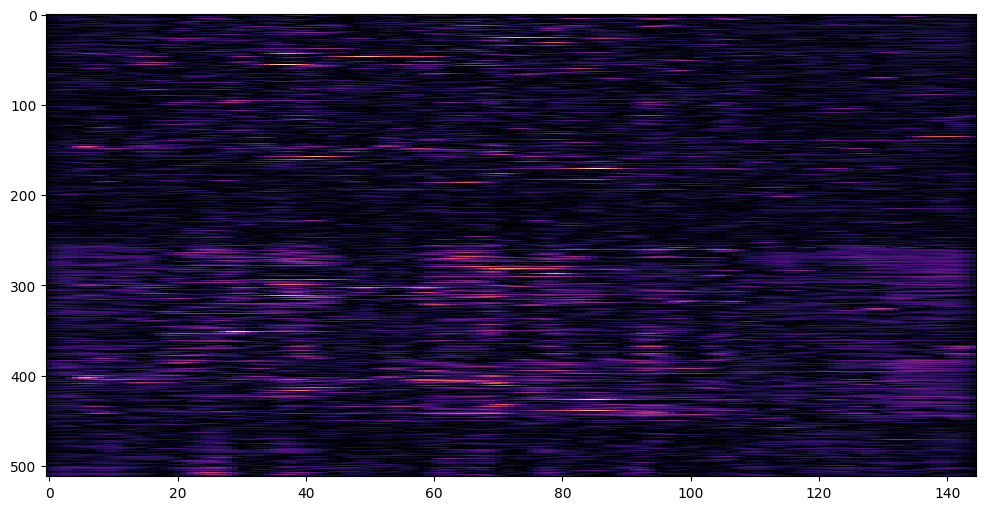

In [ ]:
# stack the same frequency layer across all dimensions. When nperseg = and noverlap = 28, STFT output freq bins = 17
layer = 0    # which frequency layer to check
specific_layer = stft_array[:, layer, :]
print("specific_layer shape:", specific_layer.shape)  # (C, T_stft)

plt.figure(figsize=(12, 6))
im = plt.imshow(
    specific_layer,                  # (C, T_stft)
    aspect='auto',
    interpolation='nearest',
    cmap='magma',         # could be 'viridis'/'cividis'/'turbo'/'magma'
    # vmin=vmin, vmax=vmax
)